# 📈 Layer Global Graph Metrics Analysis – HCB & Naples Cohorts

This analysis compares **global graph metrics** derived from brain connectivity networks across clinical groups (**Control vs EM**) and layers (**FA, GM & rsfMRI**) for both **HCB** and **Naples** cohorts.

---

## 🔄 What this analysis does

### 1. 🧬 Load clinical data
- Reads `.csv` files containing clinical information per subject.
- Renames subject ID columns to `'Subject'`.
- Creates a new `'Group'` column using:
  - `controls_ms` (for HCB)
  - `GROUP` (for Naples)
  - Values: `0 → Control`, `1 → EM`

### 2. 📊 Load and tag global graph metrics
- Loads `.xlsx` files with **global metrics** (one row per subject).
- Adds a `'Layer'` column to distinguish between:
  - FA, GM, rsfMRI
- Concatenates all layers into one DataFrame.

### 3. 🔗 Merge graph metrics with clinical data
- Inner join on `'Subject'` to retain only valid individuals.
- Final merged dataset includes metrics + group label.

### 4. 📦 Metrics included
The following metrics are computed for each subject and each network layer:
- **density**: proportion of present edges relative to all possible edges
- **average_clustering**: average of local clustering coefficients
- **global_efficiency**: how efficiently information is exchanged over the network
- **average_shortest_path**: mean shortest path between all pairs of nodes

---

## 📈 Visualization: Boxplots by Layer and Group

Using `FacetGrid` (seaborn), one boxplot per metric is displayed across all layers. These allow quick inspection of **differences between clinical groups** (Control vs EM) within each layer.

---

## 📊 Summary Statistics

The pipeline generates a summary table with:
- **Mean and standard deviation** for each metric
- Stratified by **Layer** and **Group**

---

## 🔍 Correlation with Clinical Scores

The pipeline also computes **Pearson correlations** between:
- Graph metrics (e.g., density, efficiency)
- Clinical variables (e.g., `EDSS`, `Disease Duration (DD)`)

> This helps explore associations between network topology and clinical severity.

---

## ✅ Outputs

- `df_merged_hcb`, `df_merged_naples`: merged DataFrames with clinical + metric data
- `summary_hcb`, `summary_naples`: group-level metric means & SDs
- `corrs_hcb`, `corrs_naples`: correlation matrices (metric × clinical variable)
- 📊 Visualizations: boxplots for each metric by group and layer


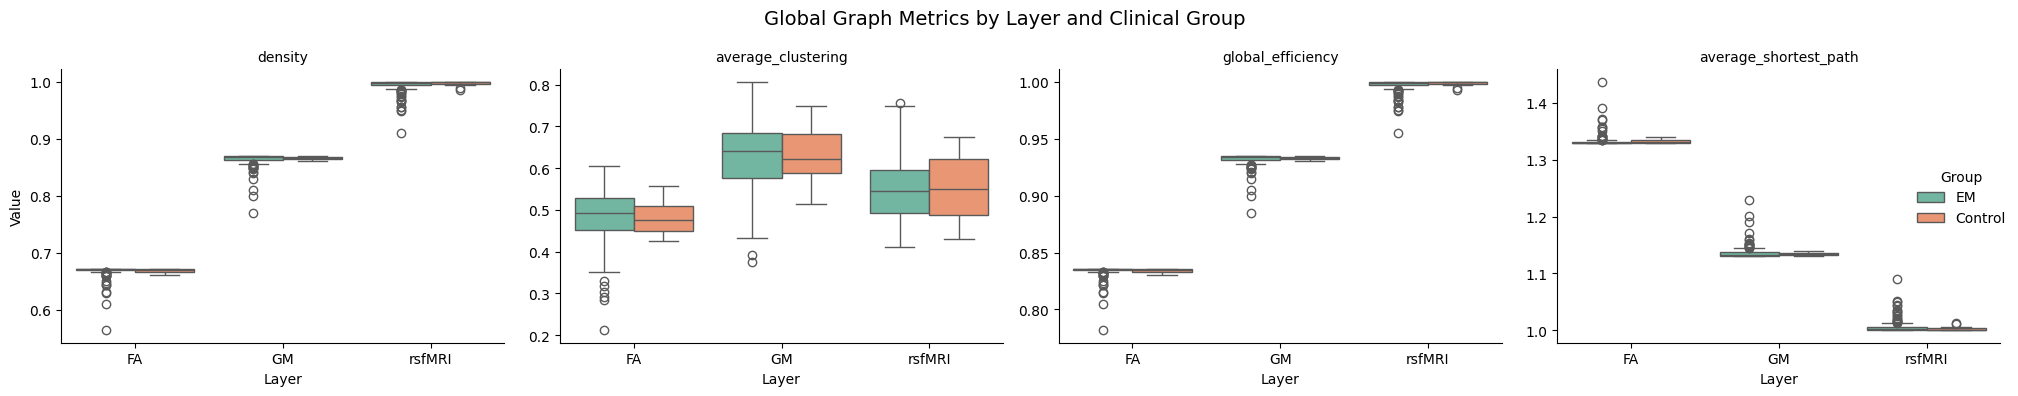

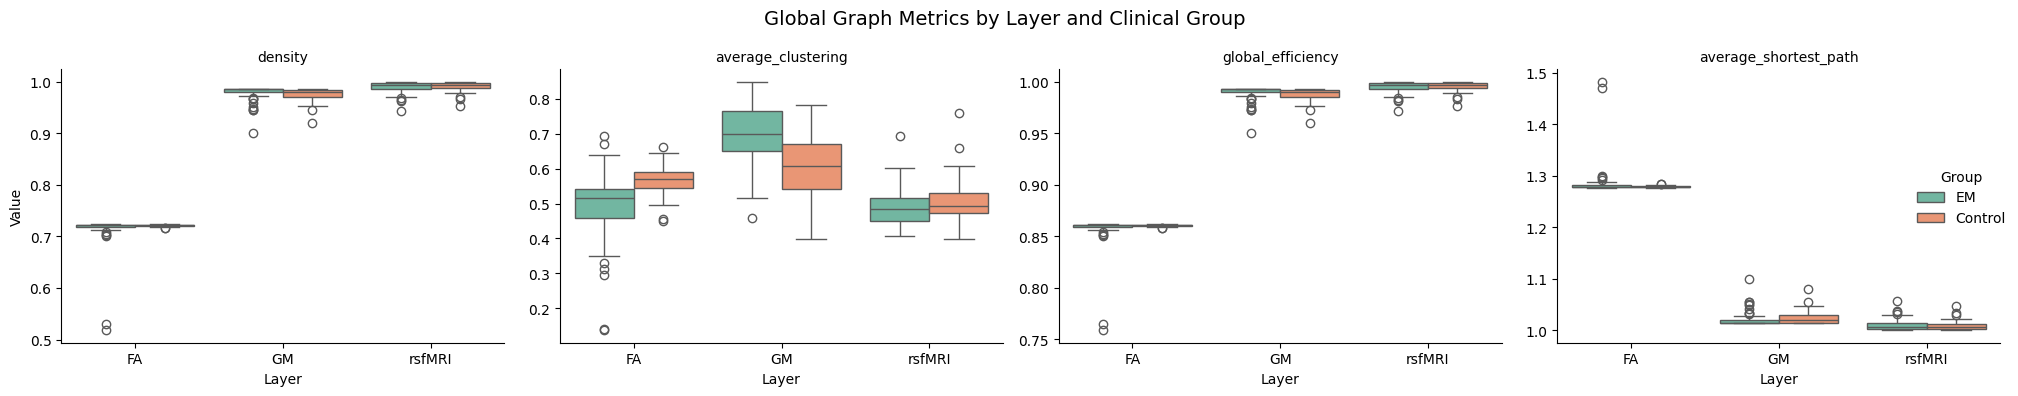

In [1]:
import os
#import numpy as np
import pandas as pd
#import networkx as nx
#from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

# ==============================================
# 🧠 GRAPH METRICS ANALYSIS - HCB & Naples
#   (clinical data in .pkl, graph metrics in .xls/.xlsx)
# ==============================================

# ================================
# Load clinical data
# ================================
def load_clinical_data(hcb_csv, naples_csv,
                       hcb_id_col='id', naples_id_col='ID'):
    """
    Load clinical DataFrames from .csv files,
    rename their ID columns to 'Subject', and standardize Group.
    """
    df_hcb = pd.read_csv(hcb_csv).reset_index()
    df_naples = pd.read_csv(naples_csv).reset_index()

    df_hcb = df_hcb.rename(columns={hcb_id_col: 'Subject'})
    df_naples = df_naples.rename(columns={naples_id_col: 'Subject'})

    df_hcb['Group'] = df_hcb['controls_ms'].map({0: 'Control', 1: 'EM'})
    df_naples['Group'] = df_naples['GROUP'].map({0: 'Control', 1: 'EM'})

    return df_hcb, df_naples

# ================================
# Load & tag global graph metrics
# ================================
def load_global_graph_data(paths_dict):
    """
    Load global‐graph metrics from Excel files,
    ensure 'Subject' is a column, and add a 'Layer' tag.
    """
    dfs = []
    for layer, path in paths_dict.items():
        # Read the sheet, taking the first column as the Subject index
        df = pd.read_excel(path, index_col=0).reset_index()
        # After reset_index(), the index name (Subject) becomes a column
        # If for some reason it's called 'index', rename it:
        if 'index' in df.columns:
            df = df.rename(columns={'index': 'Subject'})
        df['Layer'] = layer
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# ================================
# Filter & merge data
# ================================
def merge_with_clinical(global_df, clinical_df):
    """
    Keep only clinical entries whose Subject appears in global_df,
    then inner-merge on 'Subject'.
    """
    valid = set(global_df['Subject'])
    clinical_filt = clinical_df[clinical_df['Subject'].isin(valid)].copy()
    return global_df.merge(clinical_filt, on='Subject', how='inner')

# ====================================
# Plot global metrics by group
# ====================================
def plot_metrics_facet_by_metric(df):
    """
    Plots boxplots of each global graph metric across layers and groups,
    with one subplot per metric, all arranged in a single row.

    Parameters:
    - df: DataFrame containing global metrics, layers and group labels.
    """

    # Select relevant columns
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']
    base_cols = ['Subject', 'Layer', 'Group']
    df_clean = df[base_cols + metric_cols].copy()

    # Melt to long format
    melted = df_clean.melt(
        id_vars=base_cols,
        var_name='Metric',
        value_name='Value'
    )

    # Create FacetGrid with one plot per metric
    g = sns.FacetGrid(melted, col='Metric', col_order=metric_cols,
                      height=4, aspect=1.2, sharey=False)

    # Plot boxplots with hue as clinical group and style per Layer
    g.map_dataframe(sns.boxplot, x='Layer', y='Value', hue='Group', palette='Set2')

    # Improve layout
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Layer", "Value")
    g.add_legend(title='Group')
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle("Global Graph Metrics by Layer and Clinical Group", fontsize=14)
    plt.tight_layout()
    plt.show()

# ====================================
# Summarize global metrics
# ====================================
def summarize_global_metrics(df):
    # Exclde non-numeric columns
    base_cols = ['Subject', 'Layer', 'Group']
    #metric_cols = [col for col in df.columns
    #               if col not in base_cols and pd.api.types.is_numeric_dtype(df[col])]
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    return df.groupby(['Layer', 'Group'])[metric_cols].agg(['mean', 'std'])

# =========================================
# Correlate metrics with clinical vars
# =========================================
def correlate_with_clinical(global_df, variables=['EDSS', 'DD']):
    """
    Computes Pearson correlation between graph metrics and clinical variables.

    Parameters:
        global_df: DataFrame with graph metrics and clinical data.
        variables: List of clinical variables (column names) to correlate.

    Returns:
        DataFrame: graph metrics × clinical variables correlation values.
    """
    results = {}
    metrics = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    for metric in metrics:
        for var in variables:
            corr = global_df[[metric, var]].corr().iloc[0, 1]
            results[(metric, var)] = corr

    return pd.Series(results).unstack()


# =======================================
# Usage
# =======================================
# Paths to clinical .pkl files (adjust ID column names if needed)
hcb_clinic_csv    = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv"
naples_clinic_csv = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_Naples_B.csv"

# Paths to Excel graph‐metrics
hcb_paths_global = {
    "FA":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_FA_matrices_regression_re/global_graph_metrics_FA.xlsx",
    "GM":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_GM_matrices_regression_re/global_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_rsfMRI_matrices_regression_re/global_graph_metrics_rsfMRI.xlsx",
   
}
naples_paths_global = {
    "FA":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_FA_matrices_regression_re/global_graph_metrics_FA.xlsx",
    "GM":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_GM_matrices_regression_re/global_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_rsfMRI_matrices_regression_re/global_graph_metrics_rsfMRI.xlsx",
  
}


# Load clinical and graph data
df_hcb_clinic, df_naples_clinic = load_clinical_data(
    hcb_clinic_csv, naples_clinic_csv,
    hcb_id_col='id', naples_id_col='ID'  
)
df_global_hcb    = load_global_graph_data(hcb_paths_global)
df_global_naples = load_global_graph_data(naples_paths_global)

# Filter & merge
df_merged_hcb    = merge_with_clinical(df_global_hcb, df_hcb_clinic)
df_merged_naples = merge_with_clinical(df_global_naples, df_naples_clinic)

# Plot comparisons
plot_metrics_facet_by_metric(df_merged_hcb)
plot_metrics_facet_by_metric(df_merged_naples)

# Summaries & Correlations
summary_hcb    = summarize_global_metrics(df_merged_hcb)
summary_naples = summarize_global_metrics(df_merged_naples)
corrs_hcb  = correlate_with_clinical(df_merged_hcb, variables=['dd', 'edss'])
corrs_naples  = correlate_with_clinical(df_merged_naples, variables=['DD', 'EDSS'])


In [2]:
# Display results
print("HCB Summary\n", summary_hcb)
#summary_hcb.info()
#summary_hcb.describe

HCB Summary
                  density           average_clustering            \
                    mean       std               mean       std   
Layer  Group                                                      
FA     Control  0.667661  0.003554           0.480897  0.041222   
       EM       0.667434  0.011923           0.484858  0.066515   
GM     Control  0.865579  0.002705           0.626351  0.075736   
       EM       0.863373  0.012373           0.625435  0.086488   
rsfMRI Control  0.997076  0.003957           0.550511  0.084191   
       EM       0.993466  0.012105           0.548746  0.073552   

               global_efficiency           average_shortest_path            
                            mean       std                  mean       std  
Layer  Group                                                                
FA     Control          0.833772  0.001777              1.332690  0.003554  
       EM               0.833658  0.005962              1.332917  0.011923 

# 🧠 Global Graph Metric Comparison (HCB Cohort)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects across three network layers: **FA**, **GM** & **rsfMRI**.

Each metric is interpreted to reflect potential disruptions in network topology associated with MS.

---

## 🟦 FA (Structural Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                             |
|----------------------|-----------|-----------|--------------|--------------------------------------------|
| **Density**          | 0.6677    | 0.6674    | 🔻 −0.0003   | Practically identical structural density  |
| **Clustering**       | 0.4809    | 0.4849    | 🔺 +0.0040   | Slight increase in local organization in MS |
| **Efficiency**       | 0.8338    | 0.8337    | 🔻 −0.0001   | Negligible decrease in integration         |
| **Shortest Path**    | 1.3327    | 1.3329    | 🔺 +0.0002   | Slightly longer communication paths in MS  |

✅ *FA layer shows extremely minor differences between Control and MS.*

---

## 🟩 GM (Morphological Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                              |
|----------------------|-----------|-----------|--------------|---------------------------------------------|
| **Density**          | 0.8656    | 0.8634    | 🔻 −0.0022   | Slight decrease in morphological density in MS |
| **Clustering**       | 0.6264    | 0.6254    | 🔻 −0.0010   | Almost identical local organization         |
| **Efficiency**       | 0.9328    | 0.9317    | 🔻 −0.0011   | Slight reduction in global integration      |
| **Shortest Path**    | 1.1344    | 1.1366    | 🔺 +0.0022   | Slightly longer paths in MS                 |

✅ *GM layer remains very stable, minimal impact detected.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                              |
|----------------------|-----------|-----------|--------------|---------------------------------------------|
| **Density**          | 0.9971    | 0.9935    | 🔻 −0.0036   | Slight decrease in functional connectivity  |
| **Clustering**       | 0.5505    | 0.5487    | 🔻 −0.0018   | Small drop in local functional cohesion    |
| **Efficiency**       | 0.9985    | 0.9967    | 🔻 −0.0018   | Slight decrease in global integration      |
| **Shortest Path**    | 1.0029    | 1.0065    | 🔺 +0.0036   | Longer communication paths in MS           |

✅ *rsfMRI layer shows early subtle signs of network disconnection in MS.*

---

## 🔚 Summary

- **MS subjects show extremely minor reductions** in density, clustering, and efficiency across FA and rsfMRI layers.
- **GM network topology remains highly preserved** in the HCB cohort.
- **Variability** (standard deviation) is slightly greater in MS subjects, indicating possible network instability.


In [3]:
print("\nNaples Summary\n", summary_naples)


Naples Summary
                  density           average_clustering            \
                    mean       std               mean       std   
Layer  Group                                                      
FA     Control  0.721655  0.001632           0.566322  0.043042   
       EM       0.712186  0.038378           0.488973  0.110064   
GM     Control  0.975842  0.012594           0.603365  0.081757   
       EM       0.978725  0.015991           0.691240  0.084430   
rsfMRI Control  0.991433  0.009221           0.506617  0.057585   
       EM       0.989501  0.011474           0.491910  0.052491   

               global_efficiency           average_shortest_path            
                            mean       std                  mean       std  
Layer  Group                                                                
FA     Control          0.860769  0.000816              1.278696  0.001632  
       EM               0.856032  0.019189              1.288178  0.038

# 🧠 Global Graph Metric Comparison (Naples Cohort)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects across three network layers: **FA**, **GM** & **rsfMRI**.

Each metric is interpreted to reflect potential disruptions in network topology associated with MS.

---

## 🟦 FA (Structural Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                             |
|----------------------|-----------|-----------|--------------|--------------------------------------------|
| **Density**          | 0.7217    | 0.7122    | 🔻 −0.0095   | Noticeable loss of structural connections in MS |
| **Clustering**       | 0.5663    | 0.4890    | 🔻 −0.0773   | Reduced local clustering in MS             |
| **Efficiency**       | 0.8608    | 0.8560    | 🔻 −0.0048   | Slightly less integration in MS             |
| **Shortest Path**    | 1.2787    | 1.2882    | 🔺 +0.0095   | Longer communication paths in MS           |

✅ *FA layer shows moderate structural network deterioration in MS subjects.*

---

## 🟩 GM (Morphological Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                              |
|----------------------|-----------|-----------|--------------|---------------------------------------------|
| **Density**          | 0.9758    | 0.9787    | 🔺 +0.0029   | Slight increase in morphological density in MS |
| **Clustering**       | 0.6034    | 0.6912    | 🔺 +0.0878   | Marked increase in local clustering in MS  |
| **Efficiency**       | 0.9879    | 0.9894    | 🔺 +0.0015   | Slight gain in global efficiency            |
| **Shortest Path**    | 1.0242    | 1.0213    | 🔻 −0.0029   | Slightly shorter paths in MS                |

✅ *GM layer suggests possible compensatory morphological reorganization in MS.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric               | Control   | EM        | Δ (C − EM)   | Interpretation                              |
|----------------------|-----------|-----------|--------------|---------------------------------------------|
| **Density**          | 0.9914    | 0.9895    | 🔻 −0.0019   | Slight functional connectivity loss in MS  |
| **Clustering**       | 0.5066    | 0.4919    | 🔻 −0.0147   | Reduced local functional cohesion          |
| **Efficiency**       | 0.9957    | 0.9948    | 🔻 −0.0009   | Slight reduction in global integration     |
| **Shortest Path**    | 1.0086    | 1.0105    | 🔺 +0.0019   | Slightly longer communication paths        |

✅ *rsfMRI layer shows mild functional network weakening in MS subjects.*

---

## 🔚 Summary

- **FA layer shows clear structural network disruptions** in MS (loss of density and clustering).
- **GM layer surprisingly shows increased clustering**, suggesting **possible compensatory morphometric adaptation**.
- **rsfMRI layer shows subtle functional disconnection** in MS.
- **Overall**, Naples cohort shows slightly **more marked alterations** compared to HCB.



In [4]:
print("\nHCB Correlations\n", corrs_hcb.round(3))


HCB Correlations
                          dd   edss
average_clustering    -0.04 -0.048
average_shortest_path  0.01  0.006
density               -0.01 -0.006
global_efficiency     -0.01 -0.006


In [5]:
print("\nNaples Correlations\n", corrs_naples.round(3))


Naples Correlations
                           DD   EDSS
average_clustering    -0.041 -0.116
average_shortest_path  0.020  0.032
density               -0.020 -0.032
global_efficiency     -0.020 -0.032


# 📊 Correlation Between Global Graph Metrics and Clinical Variables

We computed Pearson correlations between global graph metrics and two clinical variables:
- **EDSS** (Expanded Disability Status Scale): higher values indicate greater disability.
- **DD** (Disease Duration): time (in years) since MS diagnosis.

---

## 📌 What Each Graph Metric Means

| **Metric**              | **Interpretation**                                                                 |
|-------------------------|------------------------------------------------------------------------------------|
| **Density**             | Fraction of actual connections vs. all possible connections in the graph.         |
| **Average Clustering**  | How strongly nodes form local clusters (triangles) — reflects local segregation.  |
| **Global Efficiency**   | Inverse of average path length — higher = better global information flow.         |
| **Average Shortest Path** | Average minimal path length between all node pairs — lower = more efficient.      |

---

## 🧠 HCB Cohort: Correlations with Clinical Variables

| Metric                  | `dd`      | `edss`    | Interpretation                                          |  
|--------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`     | -0.040     | -0.048    | Very weak reduction in clustering with greater severity  |  
| `average_shortest_path`  | +0.010     | +0.006    | Negligible increase in path length                      |  
| `density`                | -0.010     | -0.006    | Minimal decrease in network density                     |  
| `global_efficiency`      | -0.010     | -0.006    | Minimal reduction in global efficiency                  |

---

### General Interpretation:

- **Mild disconnection trend**: Negative correlations in `density`, `global_efficiency`, and `clustering` suggest a slight loss of global network organization with increased disease duration or severity.
- **Very weak clinical effect**: All coefficients are low (all < |0.05|), indicating no strong correlations, but hinting at gradual progression-related changes.
- **Positive `average_shortest_path`**: Indicates that communication between brain regions may require slightly longer paths in subjects with more advanced MS.

---

## 🧠 Naples Cohort: Correlations with Clinical Variables


| Metric                  | `DD`      | `EDSS`    | Interpretation                                          |  
|--------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`     | -0.041     | -0.116    | Weak reduction in clustering with greater severity       |  
| `average_shortest_path`  | +0.020     | +0.032    | Very slight increase in communication path length        |  
| `density`                | -0.020     | -0.032    | Very mild decrease in connection density                 |  
| `global_efficiency`      | -0.020     | -0.032    | Very mild reduction in global efficiency                 |

---

### General Interpretation:

- **Clearer trends than in HCB**: Correlations, especially with `EDSS`, are stronger here — particularly in `clustering`, `density`, and `efficiency`.
- **Negative correlations**: Suggest a weakening of global connectivity and network integration as MS severity increases.
- **Positive `average_shortest_path`**: Indicates that information may flow through longer or less direct routes in more impaired patients.

## 🔚 Overall Summary

- **Slightly stronger negative trends** observed in the Naples cohort, especially between `average_clustering` and `EDSS` (−0.116).
- **Still weak correlations overall** (all coefficients < |0.2|).
- Results suggest a **mild functional weakening** associated with clinical severity but **no strong effects**.



In [6]:

from scipy.stats import ttest_ind

# ============================================
# Compare graph metrics between groups
# ============================================

def compare_groups(df, metrics=['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']):
    """
    Performs independent t-tests (Control vs EM) for each graph metric within each layer.
    
    Parameters:
    - df: Merged DataFrame with graph metrics and clinical labels
    - metrics: List of global metrics to compare
    
    Returns:
    - A DataFrame with t-statistics and p-values per metric and layer
    """
    results = []
    for layer in df['Layer'].unique():
        for metric in metrics:
            sub = df[df['Layer'] == layer]
            group1 = sub[sub['Group'] == 'Control'][metric]
            group2 = sub[sub['Group'] == 'EM'][metric]
            stat, pval = ttest_ind(group1, group2, equal_var=False, nan_policy='omit')
            results.append({
                'Layer': layer,
                'Metric': metric,
                't-statistic': stat,
                'p-value': pval
            })
    return pd.DataFrame(results)

# =======================================
# Correlation across network layers
# =======================================

def inter_layer_correlations(df, metric='global_efficiency'):
    """
    Computes correlation of a given graph metric between FA, GM, and rsfMRI layers.
    
    Parameters:
    - df: Merged DataFrame
    - metric: Metric to compare across layers
    
    Returns:
    - Correlation matrix of shape (Layer x Layer)
    """
    df_wide = df.pivot(index='Subject', columns='Layer', values=metric)
    return df_wide.corr()

results_hcb = compare_groups(df_merged_hcb)
results_naples = compare_groups(df_merged_naples)

inter_corr_hcb_ge = inter_layer_correlations(df_merged_hcb, metric='global_efficiency')
inter_corr_naples_ge = inter_layer_correlations(df_merged_naples, metric='global_efficiency')

inter_corr_hcb_de = inter_layer_correlations(df_merged_hcb, metric='density')
inter_corr_naples_de = inter_layer_correlations(df_merged_naples, metric='density')

inter_corr_hcb_ac = inter_layer_correlations(df_merged_hcb, metric='average_clustering')
inter_corr_naples_ac = inter_layer_correlations(df_merged_naples, metric='average_clustering')

inter_corr_hcb_as = inter_layer_correlations(df_merged_hcb, metric='average_shortest_path')
inter_corr_naples_as = inter_layer_correlations(df_merged_naples, metric='average_shortest_path')


In [7]:
print("\nHCB group comparation\n", results_hcb.round(3))


HCB group comparation
      Layer                 Metric  t-statistic  p-value
0       FA                density        0.175    0.861
1       FA     average_clustering       -0.354    0.726
2       FA      global_efficiency        0.175    0.861
3       FA  average_shortest_path       -0.175    0.861
4       GM                density        1.650    0.106
5       GM     average_clustering        0.037    0.971
6       GM      global_efficiency        1.650    0.106
7       GM  average_shortest_path       -1.650    0.106
8   rsfMRI                density        2.632    0.010
9   rsfMRI     average_clustering        0.085    0.933
10  rsfMRI      global_efficiency        2.632    0.010
11  rsfMRI  average_shortest_path       -2.632    0.010


# 🧠 Group Comparison of Global Graph Metrics — HCB Cohort

We compared **Control** vs **MS (EM)** groups across **global graph metrics** for each network layer (**FA**, **GM**, **rsfMRI**) using independent t-tests.

---

## 📌 Test Details
- **Test used**: Welch's t-test (independent samples, unequal variances assumed).
- **Metrics compared**: `density`, `average_clustering`, `global_efficiency`, `average_shortest_path`.
- **Significance threshold**: p < 0.05.

---

## 🟦 FA (Structural Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                            |
|--------------------------|-------------|---------|-------------------------------------------|
| **Density**              | +0.175      | 0.861   | No significant difference                |
| **Average Clustering**   | -0.354      | 0.726   | No significant difference                |
| **Global Efficiency**    | +0.175      | 0.861   | No significant difference                |
| **Average Shortest Path**| -0.175      | 0.861   | No significant difference                |

✅ *FA layer shows no statistically significant differences between Control and MS groups.*

---

## 🟩 GM (Morphological Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                            |
|--------------------------|-------------|---------|-------------------------------------------|
| **Density**              | +1.650      | 0.106   | No significant difference                |
| **Average Clustering**   | +0.037      | 0.971   | No significant difference                |
| **Global Efficiency**    | +1.650      | 0.106   | No significant difference                |
| **Average Shortest Path**| -1.650      | 0.106   | No significant difference                |

✅ *GM layer shows a non-significant trend toward lower density and efficiency in MS, but no statistically significant differences.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                            |
|--------------------------|-------------|---------|-------------------------------------------|
| **Density**              | +2.632      | 0.010   | **Significant increase in Controls**      |
| **Average Clustering**   | +0.085      | 0.933   | No significant difference                |
| **Global Efficiency**    | +2.632      | 0.010   | **Significant increase in Controls**      |
| **Average Shortest Path**| -2.632      | 0.010   | **Significant decrease in Controls**      |

✅ *rsfMRI layer shows significant differences: Controls have higher density and efficiency, and shorter communication paths compared to MS subjects.*

---

## 🔚 Summary

- **FA and GM layers**: No statistically significant differences between Control and MS.
- **rsfMRI layer**: 
  - **Controls** show **higher functional connectivity and efficiency**, and **shorter paths**.
  - Indicates **early functional network disconnection** in MS subjects.

---


In [8]:
print("\nNaples group comparation\n", results_naples.round(3))


Naples group comparation
      Layer                 Metric  t-statistic  p-value
0       FA                density        1.778    0.081
1       FA     average_clustering        4.726    0.000
2       FA      global_efficiency        1.778    0.081
3       FA  average_shortest_path       -1.780    0.081
4       GM                density       -1.025    0.308
5       GM     average_clustering       -5.417    0.000
6       GM      global_efficiency       -1.025    0.308
7       GM  average_shortest_path        1.025    0.308
8   rsfMRI                density        0.950    0.344
9   rsfMRI     average_clustering        1.368    0.174
10  rsfMRI      global_efficiency        0.950    0.344
11  rsfMRI  average_shortest_path       -0.950    0.344


# 🧠 Group Comparison of Global Graph Metrics — Naples Cohort

We compared **Control** vs **MS (EM)** groups across **global graph metrics** for each network layer (**FA**, **GM**, **rsfMRI**) using independent t-tests.

---

## 📌 Test Details
- **Test used**: Welch's t-test (independent samples, unequal variances assumed).
- **Metrics compared**: `density`, `average_clustering`, `global_efficiency`, `average_shortest_path`.
- **Significance threshold**: p < 0.05.

---

## 🟦 FA (Structural Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                                |
|--------------------------|-------------|---------|-----------------------------------------------|
| **Density**              | +1.778      | 0.081   | No significant difference (trend)             |
| **Average Clustering**   | +4.726      | 0.000   | **Highly significant increase in Controls**   |
| **Global Efficiency**    | +1.778      | 0.081   | No significant difference (trend)             |
| **Average Shortest Path**| -1.780      | 0.081   | No significant difference (trend)             |

✅ *In the FA layer, only average clustering shows a strong significant difference (higher in Controls).*

---

## 🟩 GM (Morphological Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                                |
|--------------------------|-------------|---------|-----------------------------------------------|
| **Density**              | -1.025      | 0.308   | No significant difference                    |
| **Average Clustering**   | -5.417      | 0.000   | **Highly significant decrease in MS**         |
| **Global Efficiency**    | -1.025      | 0.308   | No significant difference                    |
| **Average Shortest Path**| +1.025      | 0.308   | No significant difference                    |

✅ *In the GM layer, only average clustering shows a strong significant decrease in MS subjects.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric                  | t-statistic | p-value | Interpretation                                |
|--------------------------|-------------|---------|-----------------------------------------------|
| **Density**              | +0.950      | 0.344   | No significant difference                    |
| **Average Clustering**   | +1.368      | 0.174   | No significant difference                    |
| **Global Efficiency**    | +0.950      | 0.344   | No significant difference                    |
| **Average Shortest Path**| -0.950      | 0.344   | No significant difference                    |

✅ *rsfMRI layer shows no statistically significant differences between Control and MS groups.*

---

## 🔚 Summary

- **FA layer**:
  - Only **average clustering** significantly differs (higher in Controls).
- **GM layer**:
  - Only **average clustering** significantly differs (lower in MS).
- **rsfMRI layer**:
  - No significant differences detected.
- **General pattern**:
  - Structural (FA) and morphological (GM) layers show changes mainly in **local segregation** (`average_clustering`) rather than in overall integration (`efficiency`, `density`).

---


In [9]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))


HCB inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000  0.189   0.016
GM      0.189  1.000  -0.059
rsfMRI  0.016 -0.059   1.000


# 🔗 Inter-Layer Correlation of Global Efficiency — HCB Cohort

We computed Pearson correlations of **global efficiency** between the three network layers:
- **FA** (Structural connectivity)
- **GM** (Morphological connectivity)
- **rsfMRI** (Functional connectivity)

---

## 📊 Correlation Matrix

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | 0.189  | 0.016  |
| **GM**  | 0.189  | 1.000  | -0.059 |
| **rsfMRI** | 0.016  | -0.059 | 1.000  |

---

## 🔎 Interpretation

- **FA vs GM**: Weak positive correlation (**r = 0.189**)
  - Suggests a **small alignment** between structural and morphological integration.
- **FA vs rsfMRI**: Very weak correlation (**r = 0.016**)
  - Structural and functional efficiency are **almost independent**.
- **GM vs rsfMRI**: Very weak negative correlation (**r = -0.059**)
  - Morphological and functional integration show **minimal inverse relationship**.

✅ *Overall, in the HCB cohort, the three layers operate largely independently in terms of global efficiency.*



In [10]:
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.071   0.166
GM     -0.071  1.000  -0.019
rsfMRI  0.166 -0.019   1.000


# 🔗 Inter-Layer Correlation of Global Efficiency — Naples Cohort

We computed Pearson correlations of **global efficiency** between the three network layers:
- **FA** (Structural connectivity)
- **GM** (Morphological connectivity)
- **rsfMRI** (Functional connectivity)
---
## 📊 Correlation Matrix

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | -0.071 | 0.166  |
| **GM**  | -0.071 | 1.000  | -0.019 |
| **rsfMRI** | 0.166  | -0.019 | 1.000  |

---

## 🔎 Interpretation

- **FA vs GM**: Very weak negative correlation (**r = -0.071**)
  - Suggests a **slight decoupling** between structural and morphological integration.
- **FA vs rsfMRI**: Weak positive correlation (**r = 0.166**)
  - Small tendency for structural and functional efficiency to align.
- **GM vs rsfMRI**: Almost no correlation (**r = -0.019**)
  - Morphological and functional integration are largely **independent**.

✅ *In the Naples cohort, inter-layer relationships are generally weak, with a slight trend of FA aligning better with rsfMRI compared to GM.*



In [11]:
print("\nNaples inter correlation - Density\n", inter_corr_naples_de.round(3))
print("\nNaples inter correlation - Average_clustering\n", inter_corr_naples_ac.round(3))
print("\nNaples inter correlation - Average_shortest_path\n", inter_corr_naples_as.round(3))
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Density
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.071   0.166
GM     -0.071  1.000  -0.019
rsfMRI  0.166 -0.019   1.000

Naples inter correlation - Average_clustering
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.352   0.187
GM     -0.352  1.000  -0.031
rsfMRI  0.187 -0.031   1.000

Naples inter correlation - Average_shortest_path
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.071   0.166
GM     -0.071  1.000  -0.019
rsfMRI  0.166 -0.019   1.000

Naples inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.071   0.166
GM     -0.071  1.000  -0.019
rsfMRI  0.166 -0.019   1.000


# 🔗 Inter-Layer Correlations — Naples Cohort

We computed Pearson correlations between **FA**, **GM**, and **rsfMRI** layers for each global graph metric in the **Naples** cohort.

---

## 📊 1. Density

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | -0.071 | 0.166  |
| **GM**  | -0.071 | 1.000  | -0.019 |
| **rsfMRI** | 0.166  | -0.019 | 1.000  |

### Interpretation:
- **FA vs GM**: Very weak negative correlation (**r = -0.071**).
- **FA vs rsfMRI**: Weak positive correlation (**r = 0.166**).
- **GM vs rsfMRI**: Very weak negative correlation (**r = -0.019**).

✅ *Structural density shows weak alignment with functional density.*

---

## 📊 2. Average Clustering

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | -0.352 | 0.187  |
| **GM**  | -0.352 | 1.000  | -0.031 |
| **rsfMRI** | 0.187  | -0.031 | 1.000  |

### Interpretation:
- **FA vs GM**: Moderate negative correlation (**r = -0.352**).
- **FA vs rsfMRI**: Weak positive correlation (**r = 0.187**).
- **GM vs rsfMRI**: Very weak negative correlation (**r = -0.031**).

✅ *Stronger decoupling observed between structural and morphological local clustering.*

---

## 📊 3. Average Shortest Path

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | -0.071 | 0.166  |
| **GM**  | -0.071 | 1.000  | -0.019 |
| **rsfMRI** | 0.166  | -0.019 | 1.000  |

### Interpretation:
- Identical to Density matrix.
- **FA vs rsfMRI** shows slight positive correlation.

✅ *Structural and functional path lengths are weakly related.*

---

## 📊 4. Global Efficiency

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | -0.071 | 0.166  |
| **GM**  | -0.071 | 1.000  | -0.019 |
| **rsfMRI** | 0.166  | -0.019 | 1.000  |

### Interpretation:
- Identical to Density and Shortest Path matrices.
- **FA vs rsfMRI** slightly aligned in global efficiency.

✅ *Small tendency for structural and functional efficiency to align, but overall weak correlations.*

---

# 📚 Overall Conclusions for Naples

- **Weak correlations** dominate between layers across all global metrics.
- **FA–rsfMRI** shows slight positive correlations (especially in density and efficiency).
- **FA–GM** shows moderate negative correlation only in **average clustering**.
- **GM–rsfMRI** layers are largely **independent** in all metrics.

---


In [12]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))
print("\nHCB inter correlation - Density\n", inter_corr_hcb_de.round(3))
print("\nHCB inter correlation - Average_clustering\n", inter_corr_hcb_ac.round(3))
print("\nHCB inter correlation - Average_shortest_path\n", inter_corr_hcb_as.round(3))


HCB inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000  0.189   0.016
GM      0.189  1.000  -0.059
rsfMRI  0.016 -0.059   1.000

HCB inter correlation - Density
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000  0.189   0.016
GM      0.189  1.000  -0.059
rsfMRI  0.016 -0.059   1.000

HCB inter correlation - Average_clustering
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000  0.033   0.282
GM      0.033  1.000  -0.013
rsfMRI  0.282 -0.013   1.000

HCB inter correlation - Average_shortest_path
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000  0.189   0.016
GM      0.189  1.000  -0.059
rsfMRI  0.016 -0.059   1.000


# 🔗 Inter-Layer Correlations — HCB Cohort

We computed Pearson correlations between **FA**, **GM**, and **rsfMRI** layers for each global graph metric in the **HCB** cohort.

---

## 📊 1. Density

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | 0.189  | 0.016  |
| **GM**  | 0.189  | 1.000  | -0.059 |
| **rsfMRI** | 0.016  | -0.059 | 1.000  |

### Interpretation:
- **FA vs GM**: Weak positive correlation (**r = 0.189**).
- **FA vs rsfMRI**: Very weak positive correlation (**r = 0.016**).
- **GM vs rsfMRI**: Very weak negative correlation (**r = -0.059**).

✅ *Structural and morphological densities are weakly aligned.*

---

## 📊 2. Average Clustering

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | 0.033  | 0.282  |
| **GM**  | 0.033  | 1.000  | -0.013 |
| **rsfMRI** | 0.282  | -0.013 | 1.000  |

### Interpretation:
- **FA vs GM**: Very weak positive correlation (**r = 0.033**).
- **FA vs rsfMRI**: Moderate positive correlation (**r = 0.282**).
- **GM vs rsfMRI**: Very weak negative correlation (**r = -0.013**).

✅ *Notable alignment between structural and functional clustering.*

---

## 📊 3. Average Shortest Path

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | 0.189  | 0.016  |
| **GM**  | 0.189  | 1.000  | -0.059 |
| **rsfMRI** | 0.016  | -0.059 | 1.000  |

### Interpretation:
- Identical to Density matrix.
- **FA vs GM**: Weak positive correlation.
- **FA vs rsfMRI**: Very weak positive correlation.

✅ *Path lengths in structural and morphological layers are slightly related.*

---

## 📊 4. Global Efficiency

| Layer   | FA     | GM     | rsfMRI |
|---------|--------|--------|--------|
| **FA**  | 1.000  | 0.189  | 0.016  |
| **GM**  | 0.189  | 1.000  | -0.059 |
| **rsfMRI** | 0.016  | -0.059 | 1.000  |

### Interpretation:
- Identical to Density and Shortest Path matrices.
- **FA vs GM**: Weak positive correlation.
- **FA vs rsfMRI**: Very weak correlation.

✅ *Global efficiencies show weak alignment between structural and morphological layers.*

---

# 📚 Overall Conclusions for HCB

- **FA–GM** correlation is consistently weak positive across density, efficiency, and shortest path (~0.19).
- **FA–rsfMRI** correlation is generally very low, except for **average clustering**, where it's **moderate** (**r = 0.282**).
- **GM–rsfMRI** correlation is near zero or weakly negative across all metrics.

---



# 📚 Global Graph Metrics Analysis — Main Conclusions

This section summarizes the key findings from the analysis of global graph metrics across the **HCB** and **Naples** cohorts.

---

## 🧠 1. Correlations with Clinical Variables (DD, EDSS)

| Cohort | Finding | Interpretation |
|:-------|:--------|:----------------|
| **HCB** | Correlations almost null | Global metrics remain stable regardless of disease progression. |
| **Naples** | Slightly stronger (e.g., clustering vs EDSS r = -0.116) | Mild functional weakening associated with higher clinical disability. |

✅ *Global metrics are poor predictors of clinical severity individually.*

---

## 🧠 2. Group Comparisons (Control vs MS)

| Cohort/Layer | Finding | Interpretation |
|:-------------|:--------|:----------------|
| **HCB FA, GM** | No significant differences | Structural and morphological networks are globally preserved. |
| **HCB rsfMRI** | Significant differences (Density, Efficiency, Shortest Path) | Early functional disconnection detected in MS. |
| **Naples FA** | Significant in Average Clustering | Better local structural organization in Controls. |
| **Naples GM** | Significant decrease in Average Clustering in MS | Morphological networks show impaired local segregation. |
| **Naples rsfMRI** | No significant differences | Functional networks appear relatively preserved. |

✅ *Functional disruptions dominate in HCB; structural/morphological disruptions dominate in Naples.*

---

## 🧠 3. Inter-Layer Correlations

| Cohort | Finding | Interpretation |
|:-------|:--------|:----------------|
| **HCB** | Weak positive FA–GM correlations (~0.19); almost independent FA–rsfMRI | Layers operate mostly independently. |
| **Naples** | FA–rsfMRI correlations slightly stronger (+0.166); FA–GM decoupling in clustering (-0.352) | Structural network relates more to functional than to morphological layers. |

✅ *Naples shows greater layer decoupling compared to HCB.*

---

## 🔬 Overall Interpretation

- **Functional disruptions appear earlier** than structural/morphological disruptions (HCB cohort).
- **Structural and morphological organization deteriorates more** in Naples cohort.
- **Global metrics alone are not sensitive enough** to capture individual clinical severity.
- **Network layers (FA, GM, rsfMRI) behave partially independently**, with weak interrelations.


